# Quantum Convolutional Neural Network (QCNN)


In [52]:
import pennylane as qml
import torch
import torch.nn as nn
from torchvision import datasets
from torch.utils.data import DataLoader,TensorDataset,Subset

import numpy as np
from sklearn.decomposition import PCA
from pathlib import Path
import joblib


# Ansatze for Convolutional and pooling layers

In [53]:
# Unitary Ansatze for Convolutional Layer
def U_TTN(params, wires):  # 2 params
    qml.RY(params[0], wires=wires[0])
    qml.RY(params[1], wires=wires[1])
    qml.CNOT(wires=[wires[0], wires[1]])


def U_5(params, wires):  # 10 params
    qml.RX(params[0], wires=wires[0])
    qml.RX(params[1], wires=wires[1])
    qml.RZ(params[2], wires=wires[0])
    qml.RZ(params[3], wires=wires[1])
    qml.CRZ(params[4], wires=[wires[1], wires[0]])
    qml.CRZ(params[5], wires=[wires[0], wires[1]])
    qml.RX(params[6], wires=wires[0])
    qml.RX(params[7], wires=wires[1])
    qml.RZ(params[8], wires=wires[0])
    qml.RZ(params[9], wires=wires[1])


def U_6(params, wires):  # 10 params
    qml.RX(params[0], wires=wires[0])
    qml.RX(params[1], wires=wires[1])
    qml.RZ(params[2], wires=wires[0])
    qml.RZ(params[3], wires=wires[1])
    qml.CRX(params[4], wires=[wires[1], wires[0]])
    qml.CRX(params[5], wires=[wires[0], wires[1]])
    qml.RX(params[6], wires=wires[0])
    qml.RX(params[7], wires=wires[1])
    qml.RZ(params[8], wires=wires[0])
    qml.RZ(params[9], wires=wires[1])


def U_9(params, wires):  # 2 params
    qml.Hadamard(wires=wires[0])
    qml.Hadamard(wires=wires[1])
    qml.CZ(wires=[wires[0], wires[1]])
    qml.RX(params[0], wires=wires[0])
    qml.RX(params[1], wires=wires[1])


def U_13(params, wires):  # 6 params
    qml.RY(params[0], wires=wires[0])
    qml.RY(params[1], wires=wires[1])
    qml.CRZ(params[2], wires=[wires[1], wires[0]])
    qml.RY(params[3], wires=wires[0])
    qml.RY(params[4], wires=wires[1])
    qml.CRZ(params[5], wires=[wires[0], wires[1]])


def U_14(params, wires):  # 6 params
    qml.RY(params[0], wires=wires[0])
    qml.RY(params[1], wires=wires[1])
    qml.CRX(params[2], wires=[wires[1], wires[0]])
    qml.RY(params[3], wires=wires[0])
    qml.RY(params[4], wires=wires[1])
    qml.CRX(params[5], wires=[wires[0], wires[1]])


def U_15(params, wires):  # 4 params
    qml.RY(params[0], wires=wires[0])
    qml.RY(params[1], wires=wires[1])
    qml.CNOT(wires=[wires[1], wires[0]])
    qml.RY(params[2], wires=wires[0])
    qml.RY(params[3], wires=wires[1])
    qml.CNOT(wires=[wires[0], wires[1]])


def U_SO4(params, wires):  # 6 params
    qml.RY(params[0], wires=wires[0])
    qml.RY(params[1], wires=wires[1])
    qml.CNOT(wires=[wires[0], wires[1]])
    qml.RY(params[2], wires=wires[0])
    qml.RY(params[3], wires=wires[1])
    qml.CNOT(wires=[wires[0], wires[1]])
    qml.RY(params[4], wires=wires[0])
    qml.RY(params[5], wires=wires[1])


def U_SU4(params, wires): # 15 params
    qml.U3(params[0], params[1], params[2], wires=wires[0])
    qml.U3(params[3], params[4], params[5], wires=wires[1])
    qml.CNOT(wires=[wires[0], wires[1]])
    qml.RY(params[6], wires=wires[0])
    qml.RZ(params[7], wires=wires[1])
    qml.CNOT(wires=[wires[1], wires[0]])
    qml.RY(params[8], wires=wires[0])
    qml.CNOT(wires=[wires[0], wires[1]])
    qml.U3(params[9], params[10], params[11], wires=wires[0])
    qml.U3(params[12], params[13], params[14], wires=wires[1])

# Pooling Layer

def Pooling_ansatz1(params, wires): #2 params
    qml.CRZ(params[0], wires=[wires[0], wires[1]])
    qml.PauliX(wires=wires[0])
    qml.CRX(params[1], wires=[wires[0], wires[1]])

def Pooling_ansatz2(wires): #0 params
    qml.CRZ(wires=[wires[0], wires[1]])

def Pooling_ansatz3(*params, wires): #3 params
    qml.CRot(*params, wires=[wires[0], wires[1]])


# QCNN Layers

In [54]:
def conv_layer(params, active_wires):

    # for knowing which parameters correspond to which gates
    idx = 0

    # even pairs
    for i in range(0, len(active_wires), 2):
        w1 = active_wires[i]
        w2 = active_wires[(i + 1) % len(active_wires)]

        U_SO4(
            params[idx:idx+6],
            wires=[w1, w2]
        )
        idx += 6

    # odd pairs
    for i in range(1, len(active_wires), 2):
        w1 = active_wires[i]
        w2 = active_wires[(i + 1) % len(active_wires)]

        U_SO4(
            params[idx:idx+6],
            wires=[w1, w2]
        )
        idx += 6

In [55]:
def pooling_layer(params, active_wires):

    idx = 0
    new_active = []

    for i in range(0, len(active_wires), 2):

        source = active_wires[i]
        target = active_wires[i+1]

        Pooling_ansatz1(
            params[idx:idx+2],
            wires=[source, target]
        )

        idx += 2

        new_active.append(target)

    return new_active

In [56]:
n_qubits = 8
dev = qml.device("default.qubit", wires=n_qubits)
N_PARAMS = 98

In [57]:
@qml.qnode(dev, interface="torch")
def qcnn_circuit(x, weights):

    qml.AmplitudeEmbedding(
        x,
        wires=range(n_qubits),
        normalize=True
    )

    ptr = 0

    active = list(range(8))

    # -------- Layer 1 --------

    conv_params = weights[ptr:ptr+48]
    ptr += 48

    conv_layer(conv_params, active)

    pool_params = weights[ptr:ptr+8]
    ptr += 8

    active = pooling_layer(pool_params, active)

    # -------- Layer 2 --------

    conv_params = weights[ptr:ptr+24]
    ptr += 24

    conv_layer(conv_params, active)

    pool_params = weights[ptr:ptr+4]
    ptr += 4

    active = pooling_layer(pool_params, active)

    # -------- Layer 3 --------

    conv_params = weights[ptr:ptr+12]
    ptr += 12

    conv_layer(conv_params, active)

    pool_params = weights[ptr:ptr+2]
    ptr += 2

    active = pooling_layer(pool_params, active)

    return qml.expval(qml.PauliZ(active[0]))

In [58]:
class QCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.q_params = nn.Parameter(
            0.01 * torch.randn(N_PARAMS)
        )

    def forward(self, x):

        outputs = []

        for sample in x:

            outputs.append(
                qcnn_circuit(sample, self.q_params)
            )

        outputs = torch.stack(outputs)

        return outputs

# Loss function definition

In [59]:
def loss_fn(pred, target):

    pred = (pred + 1) / 2

    pred = torch.clamp(
        pred,
        min=1e-7,
        max=1 - 1e-7
    )
    

    target = target.to(pred.dtype)

    return torch.nn.functional.binary_cross_entropy(
        pred,
        target
    )

# MNIST DATA

## Dimensionality reduction

In [ ]:
SAVE_DIR = Path("mnist_pca")
SAVE_DIR.mkdir(exist_ok=True)

N_COMPONENTS = 256

# -------------------------
# Load MNIST
# -------------------------

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True
)

X_train = train_dataset.data.numpy()
y_train = train_dataset.targets.numpy()

X_test = test_dataset.data.numpy()
y_test = test_dataset.targets.numpy()

# -------------------------
# Flatten
# -------------------------

X_train = X_train.reshape(len(X_train), -1)
X_test = X_test.reshape(len(X_test), -1)

# Scale to [0,1]
X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

# -------------------------
# PCA
# -------------------------

pca = PCA(
    n_components=N_COMPONENTS,
    svd_solver="randomized",
    random_state=42
)

print("Fitting PCA...")
X_train_pca = pca.fit_transform(X_train)

print("Transforming test set...")
X_test_pca = pca.transform(X_test)

print(
    "Explained variance:",
    pca.explained_variance_ratio_.sum()
)

# -------------------------
# Save transformed datasets
# -------------------------

np.save(SAVE_DIR / "X_train_pca.npy", X_train_pca)
np.save(SAVE_DIR / "y_train.npy", y_train)

np.save(SAVE_DIR / "X_test_pca.npy", X_test_pca)
np.save(SAVE_DIR / "y_test.npy", y_test)

# Save PCA object
joblib.dump(
    pca,
    SAVE_DIR / "pca_model.joblib"
)

print("Done.")

Fitting PCA...
Transforming test set...
Explained variance: 0.9789118
Done.


## Data loading
So you don´t have to recompute PCA all times

In [61]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader, Subset
import joblib

X_train = np.load("mnist_pca/X_train_pca.npy")
y_train = np.load("mnist_pca/y_train.npy")

X_test = np.load("mnist_pca/X_test_pca.npy")
y_test = np.load("mnist_pca/y_test.npy")

pca = joblib.load("mnist_pca/pca_model.joblib")




# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float64)
y_train = torch.tensor(y_train, dtype=torch.long)

X_test = torch.tensor(X_test, dtype=torch.float64)
y_test = torch.tensor(y_test, dtype=torch.long)


# Turn the problem to a binary classification one
# We just want to differentiate between 0 and 1
mask_train = (y_train == 0) | (y_train == 1)
mask_test = (y_test == 0) | (y_test == 1)

X_train = X_train[mask_train]
y_train = y_train[mask_train]

X_test = X_test[mask_test]
y_test = y_test[mask_test]


# Create datasets
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# Select first N samples
n_train_samples = 500
n_test_samples = 500

train_indices = list(range(n_train_samples))
test_indices = list(range(n_test_samples))

train_subset = Subset(train_dataset, train_indices)
test_subset = Subset(test_dataset, test_indices)

# DataLoaders
train_loader = DataLoader(
    train_subset,
    batch_size=1,
    shuffle=True
)

test_loader = DataLoader(
    test_subset,
    batch_size=1,
    shuffle=False
)

In [62]:
print("Train zeros:", (y_train[train_indices] == 0).sum())
print("Train ones :", (y_train[train_indices] == 1).sum())

Train zeros: tensor(229)
Train ones : tensor(271)


# Training loop

In [63]:
model = QCNN()
optimizer = torch.optim.Adam(model.parameters(),lr=0.01)

epochs = 20
train_losses = []
train_accuracies = []
for epoch in range(epochs):

    model.train()
    running_loss = 0
    epoch_loss=0
    correct = 0
    total = 0

    for images, labels in train_loader:
        optimizer.zero_grad()

        logits = model(images)
        loss = loss_fn(logits, labels)

        probs = (logits + 1) / 2

        predictions = (probs >= 0.5).long()

        correct += (predictions == labels).sum().item()
        total += labels.size(0)
        
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    accuracy = correct / total

    train_losses.append(epoch_loss)
    train_accuracies.append(accuracy)


    print(f'Epoch {epoch+1}: loss={running_loss/len(train_loader):.4f}')


Epoch 1: loss=0.3566
Epoch 2: loss=0.3121
Epoch 3: loss=0.3030
Epoch 4: loss=0.2992
Epoch 5: loss=0.2947
Epoch 6: loss=0.2946
Epoch 7: loss=0.2883
Epoch 8: loss=0.2899
Epoch 9: loss=0.2865
Epoch 10: loss=0.2878
Epoch 11: loss=0.2831
Epoch 12: loss=0.2811
Epoch 13: loss=0.2813
Epoch 14: loss=0.2778
Epoch 15: loss=0.2809
Epoch 16: loss=0.2788
Epoch 17: loss=0.2794
Epoch 18: loss=0.2779
Epoch 19: loss=0.2801
Epoch 20: loss=0.2816


# Plot of training process

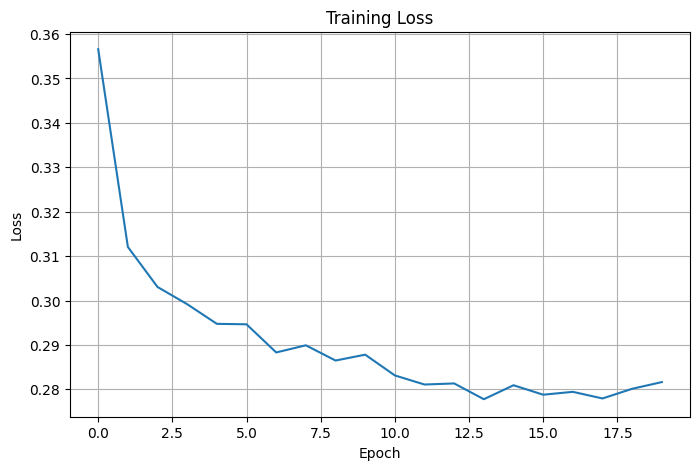

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

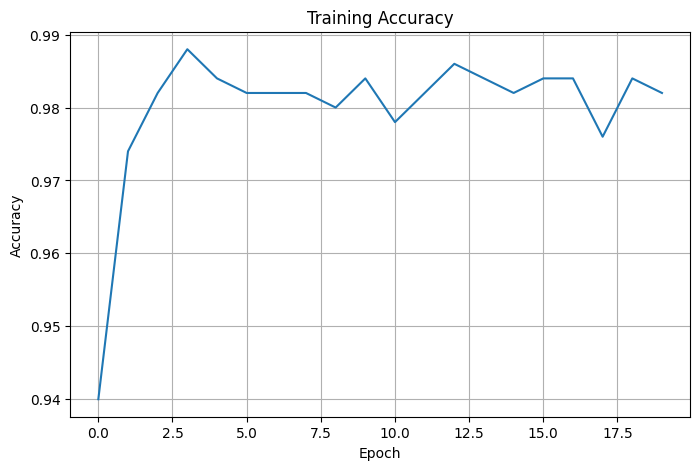

In [65]:
plt.figure(figsize=(8,5))
plt.plot(train_accuracies)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.grid(True)
plt.show()

# Test set metrics

In [67]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        logits = model(images)

        probs = (logits + 1) / 2

        preds = (probs >= 0.5).long()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

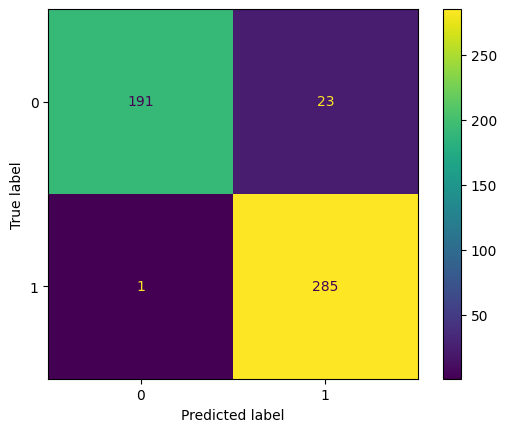

              precision    recall  f1-score   support

           0       0.99      0.89      0.94       214
           1       0.93      1.00      0.96       286

    accuracy                           0.95       500
   macro avg       0.96      0.94      0.95       500
weighted avg       0.96      0.95      0.95       500



In [68]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    all_labels,
    all_preds,
    labels=list(range(2))
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(range(2))
)

disp.plot()
plt.show()
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_preds
    )
)